# 01 - Data Exploration

**Purpose**: Load, validate, and explore the durian leaf dataset

**Input**: Raw durian leaf images in `data/raw/`

**Output**: Dataset statistics, validation reports, and processed data splits

**Constitution Compliance**: Supports classification-first approach (Principle I)

## Setup and Imports

In [1]:
import sys
import os
proj_root = r'E:\Master\thesis_durian'
sys.path.insert(0, proj_root)
sys.path.insert(0, os.path.join(proj_root, 'utils'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import json
from datetime import datetime

# Custom utilities
from utils.preprocessing import DataLoader, DurianLeafImage
from utils.visualization import DurianVisualizer

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configure matplotlib
plt.style.use('default')
sns.set_palette("husl")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cpu
CUDA available: False


## Data Directory Setup

In [2]:
# Define data directories
DATA_RAW_DIR = proj_root + "/notebooks/data/raw"
DATA_PROCESSED_DIR = "data/processed"
VISUALIZATION_DIR = "visualizations"

# Create directories if they don't exist
os.makedirs(DATA_PROCESSED_DIR, exist_ok=True)
os.makedirs(VISUALIZATION_DIR, exist_ok=True)

print(f"Raw data directory: {DATA_RAW_DIR}")
print(f"Processed data directory: {DATA_PROCESSED_DIR}")
print(f"Visualization directory: {VISUALIZATION_DIR}")

Raw data directory: E:\Master\thesis_durian/notebooks/data/raw
Processed data directory: data/processed
Visualization directory: visualizations


## Dataset Loading and Validation

In [3]:
# Initialize data loader
data_loader = DataLoader(
    data_dir=DATA_RAW_DIR,
    batch_size=32,
    image_size=(224, 224),
    random_seed=42
)

print("DataLoader initialized successfully")
print(f"Batch size: {data_loader.batch_size}")
print(f"Image size: {data_loader.image_size}")

DataLoader initialized successfully
Batch size: 32
Image size: (224, 224)


In [4]:
# Load and validate dataset
try:
    datasets = data_loader.load_dataset()
    print("✅ Dataset loaded successfully!")
    print(f"Train set: {len(datasets['train'])} images")
    print(f"Validation set: {len(datasets['val'])} images")
    print(f"Test set: {len(datasets['test'])} images")
    print(f"Total: {sum(len(v) for v in datasets.values())} images")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")
    print("Please check that your data is organized correctly in data/raw/ with class subdirectories.")

✅ Dataset loaded successfully!
Train set: 3104 images
Validation set: 443 images
Test set: 890 images
Total: 4437 images


## Class Distribution Analysis

In [5]:
# Get class distribution
class_distribution = data_loader.get_class_distribution()
print("Class distribution:")
for class_id, count in class_distribution.items():
    print(f"  Class {class_id}: {count} images")

# Check if we have the expected 5 classes
expected_classes = 5
actual_classes = len(class_distribution)
print(f"\nExpected classes: {expected_classes}")
print(f"Actual classes: {actual_classes}")

if actual_classes == expected_classes:
    print("✅ Correct number of classes detected")
else:
    print(f"⚠️  Warning: Expected {expected_classes} classes, found {actual_classes}")

Class distribution:
  Class 0: 733 images
  Class 1: 913 images
  Class 2: 976 images
  Class 3: 937 images
  Class 4: 878 images

Expected classes: 5
Actual classes: 5
✅ Correct number of classes detected


## Dataset Split Analysis

In [6]:
# Analyze split ratios
total_images = sum(len(v) for v in datasets.values())
train_ratio = len(datasets['train']) / total_images
val_ratio = len(datasets['val']) / total_images
test_ratio = len(datasets['test']) / total_images

print("Dataset split ratios:")
print(f"  Train: {train_ratio:.1%} ({len(datasets['train'])} images)")
print(f"  Validation: {val_ratio:.1%} ({len(datasets['val'])} images)")
print(f"  Test: {test_ratio:.1%} ({len(datasets['test'])} images)")

# Expected ratios (70/10/20)
expected_ratios = {'train': 0.7, 'val': 0.1, 'test': 0.2}
actual_ratios = {'train': train_ratio, 'val': val_ratio, 'test': test_ratio}
    
print("Ratio validation:")
for split, expected in expected_ratios.items():
    actual = actual_ratios[split]
    diff = abs(actual - expected)
    if diff < 0.01:  # Within 1% tolerance
        print(f"  {split}: ✅ {actual:.1%} (expected {expected:.1%})")
    else:
        print(f"  {split}: ⚠️  {actual:.1%} (expected {expected:.1%}) - difference: {diff:.1%}")

Dataset split ratios:
  Train: 70.0% (3104 images)
  Validation: 10.0% (443 images)
  Test: 20.1% (890 images)
Ratio validation:
  train: ✅ 70.0% (expected 70.0%)
  val: ✅ 10.0% (expected 10.0%)
  test: ✅ 20.1% (expected 20.0%)


## Sample Image Visualization

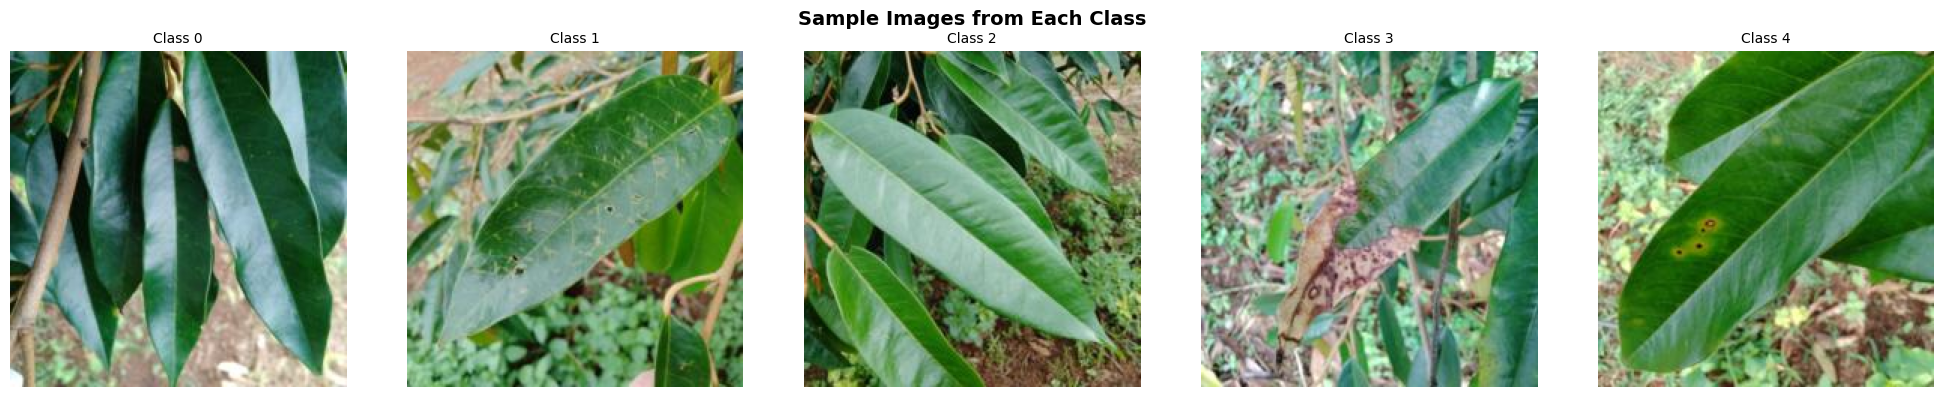

✅ Sample image grid saved to: visualizations\image_grid_20260408_231929.png


In [7]:
# Initialize visualizer
visualizer = DurianVisualizer(VISUALIZATION_DIR)

# Load sample images from each class
sample_images = []
sample_titles = []

for class_id in range(len(class_distribution)):
    # Find images of this class
    class_images = [img for img in datasets['train'] if img.class_label == class_id]
    
    if class_images:
        # Load first sample image
        sample_img = class_images[0]
        image_array = sample_img.load_and_preprocess()
        
        sample_images.append(image_array)
        sample_titles.append(f"Class {class_id}")

# Create image grid
if sample_images:
    grid_path = visualizer.create_image_grid(
        sample_images, 
        sample_titles, 
        cols=min(5, len(sample_images)),
        title="Sample Images from Each Class"
    )
    print(f"✅ Sample image grid saved to: {grid_path}")
else:
    print("❌ No sample images could be loaded")

## Image Statistics Analysis

In [8]:
# Analyze image dimensions and properties
image_stats = {
    'widths': [],
    'heights': [],
    'aspect_ratios': [],
    'file_sizes': []
}

# Sample a subset for analysis (to avoid loading all images)
sample_size = min(100, len(datasets['train']))
sample_indices = np.random.choice(len(datasets['train']), sample_size, replace=False)

print(f"Analyzing {sample_size} sample images...")

for idx in sample_indices:
    img_obj = datasets['train'][idx]
    
    # Get original dimensions
    width, height = img_obj.original_shape[:2]
    aspect_ratio = width / height if height > 0 else 0
    
    # Get file size
    try:
        file_size = os.path.getsize(img_obj.image_path) / 1024  # KB
    except:
        file_size = 0
    
    image_stats['widths'].append(width)
    image_stats['heights'].append(height)
    image_stats['aspect_ratios'].append(aspect_ratio)
    image_stats['file_sizes'].append(file_size)

# Calculate statistics
stats_summary = {}
for key, values in image_stats.items():
    if values:
        stats_summary[key] = {
            'mean': np.mean(values),
            'std': np.std(values),
            'min': np.min(values),
            'max': np.max(values),
            'median': np.median(values)
        }

print("\nImage Statistics Summary:")
for stat_name, stat_values in stats_summary.items():
    print(f"\n{stat_name.upper()}:")
    for metric, value in stat_values.items():
        if 'size' in stat_name:
            print(f"  {metric}: {value:.1f} KB")
        else:
            print(f"  {metric}: {value:.1f}")

Analyzing 100 sample images...

Image Statistics Summary:

WIDTHS:
  mean: 224.0
  std: 0.0
  min: 224.0
  max: 224.0
  median: 224.0

HEIGHTS:
  mean: 224.0
  std: 0.0
  min: 224.0
  max: 224.0
  median: 224.0

ASPECT_RATIOS:
  mean: 1.0
  std: 0.0
  min: 1.0
  max: 1.0
  median: 1.0

FILE_SIZES:
  mean: 10.9 KB
  std: 1.0 KB
  min: 8.5 KB
  max: 14.3 KB
  median: 10.8 KB


## Data Processing Pipeline Test

In [9]:
# Test data loading pipeline
print("Testing data loading pipeline...")

# Create data loaders for each split
train_loader = data_loader.get_data_loader('train', is_training=True)
val_loader = data_loader.get_data_loader('val', is_training=False)
test_loader = data_loader.get_data_loader('test', is_training=False)

print("✅ Data loaders created successfully")

# Test batch loading
try:
    # Get one batch from training set
    batch = next(iter(train_loader))
    images, labels = batch['image'], batch['label']
    
    print(f"Batch shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Image value range: [{images.min():.3f}, {images.max():.3f}]")
    print(f"Label range: [{labels.min()}, {labels.max()}]")
    
    # Check normalization (ImageNet stats)
    mean = images.mean(dim=[0, 2, 3])
    std = images.std(dim=[0, 2, 3])
    print(f"Channel means: {mean}")
    print(f"Channel stds: {std}")
    
    print("✅ Data loading pipeline working correctly")
    
except Exception as e:
    print(f"❌ Error in data loading pipeline: {e}")

Testing data loading pipeline...
✅ Data loaders created successfully
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Image value range: [-2.118, 2.640]
Label range: [0, 4]
Channel means: tensor([-0.6184,  0.0006, -0.3201])
Channel stds: tensor([1.0298, 1.0201, 1.0387])
✅ Data loading pipeline working correctly


## Save Dataset Information

In [10]:
# Save dataset split information
split_info_path = os.path.join(DATA_PROCESSED_DIR, "dataset_split.json")
data_loader.save_split_info(split_info_path)
print(f"✅ Dataset split information saved to: {split_info_path}")

# Save dataset statistics
stats_info = {
    'timestamp': datetime.now().isoformat(),
    'total_images': sum(len(v) for v in datasets.values()),
    'split_counts': {k: len(v) for k, v in datasets.items()},
    'class_distribution': class_distribution,
    'image_statistics': stats_summary,
    'data_loader_config': {
        'batch_size': data_loader.batch_size,
        'image_size': data_loader.image_size,
        'random_seed': data_loader.random_seed
    }
}

stats_path = os.path.join(DATA_PROCESSED_DIR, "dataset_statistics.json")
with open(stats_path, 'w') as f:
    json.dump(stats_info, f, indent=2, default=str)
    
print(f"✅ Dataset statistics saved to: {stats_path}")

✅ Dataset split information saved to: data/processed\dataset_split.json
✅ Dataset statistics saved to: data/processed\dataset_statistics.json


## Summary and Next Steps

In [11]:
print("=" * 60)
print("DATA EXPLORATION SUMMARY")
print("=" * 60)

print(f"Total images processed: {sum(len(v) for v in datasets.values())}")
print(f"Number of classes: {len(class_distribution)}")
print(f"Train/Val/Test split: {len(datasets['train'])}/{len(datasets['val'])}/{len(datasets['test'])}")

print("\nClass distribution:")
for class_id, count in class_distribution.items():
    percentage = count / sum(class_distribution.values()) * 100
    print(f"  Class {class_id}: {count} images ({percentage:.1f}%)")

print("\n✅ Data exploration completed successfully!")
print("\nNext steps:")
print("1. Review the generated visualizations in the visualizations/ directory")
print("2. Proceed to 02-classification-baseline.ipynb for model training")
print("3. Ensure all data preprocessing steps are working correctly")

print("\n" + "=" * 60)

DATA EXPLORATION SUMMARY
Total images processed: 4437
Number of classes: 5
Train/Val/Test split: 3104/443/890

Class distribution:
  Class 0: 733 images (16.5%)
  Class 1: 913 images (20.6%)
  Class 2: 976 images (22.0%)
  Class 3: 937 images (21.1%)
  Class 4: 878 images (19.8%)

✅ Data exploration completed successfully!

Next steps:
1. Review the generated visualizations in the visualizations/ directory
2. Proceed to 02-classification-baseline.ipynb for model training
3. Ensure all data preprocessing steps are working correctly

